# Comparing Remapping Methods in Nereus

Nereus offers five ways to regrid unstructured mesh data (FESOM, ICON, MPAS, ...) onto a
regular lat/lon grid (or, for one method, onto another unstructured mesh):

| Method | Idea | Speed | Smoothness |
|---|---|---|---|
| `"nearest"` | KDTree nearest-neighbor lookup | fastest | blocky |
| `"idw"` | inverse-distance weighting over 8 neighbors | fast | smooth |
| `"linear"` | Delaunay triangulation, barycentric interpolation | slower | smooth |
| `"cubic"` | Clough-Tocher C1 interpolation | slowest of the point methods | smoothest |
| `"conservative"` | area-weighted polygon overlap (Voronoi tessellation) | slowest to build | preserves totals, not point values |

This notebook builds a synthetic unstructured mesh with a known field, then compares all
five methods side by side: visual output, runtime, and — uniquely for `"conservative"` —
whether the *total* (integrated) quantity is preserved and how missing data is reported.

In [1]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import numpy as np

import nereus as nr
from nereus.regrid.conservative import build_voronoi_cells, geometry_spherical_area

print(f"Nereus version: {nr.__version__}")

Nereus version: 0.4.1


## 1. A synthetic unstructured mesh and test field

We use a random point cloud (standing in for an FESOM/ICON mesh) with a field that
combines a smooth pole-to-equator gradient with a sharp, localized warm anomaly — good
for showing the difference between blocky, smooth, and area-averaged remapping. A
elliptical "continent" is masked out with NaN, to later demonstrate how each method
handles missing source data.

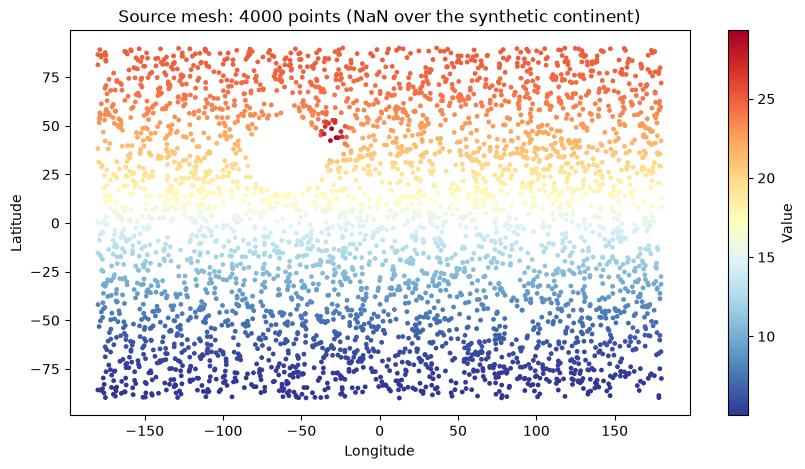

In [2]:
rng = np.random.default_rng(0)
n_source = 4000

lon = rng.uniform(-180, 180, n_source)
lat = rng.uniform(-90, 90, n_source)

# Smooth background + a sharp localized anomaly (~6 degrees wide)
background = 15 + 10 * np.sin(np.deg2rad(lat))
bump = 8 * np.exp(-(((lon - (-30)) ** 2 + (lat - 45) ** 2) / (2 * 6.0 ** 2)))
data = background + bump

# Elliptical "continent" -- masked out with NaN
continent = ((lon - (-60)) / 25.0) ** 2 + ((lat - 35) / 20.0) ** 2 < 1.0
data_masked = data.copy()
data_masked[continent] = np.nan

fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(lon, lat, c=data_masked, s=6, cmap="RdYlBu_r")
ax.set_title(f"Source mesh: {n_source} points (NaN over the synthetic continent)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(sc, label="Value", ax=ax)
plt.show()

## 2. Side-by-side comparison at 2° resolution

Each method regrids the *unmasked* field to the same 2° global grid. `"conservative"`
returns `(value, valid_fraction)` when called with `return_fraction=True`; the other
methods return a single array.

In [3]:
methods = ["nearest", "idw", "linear", "cubic", "conservative"]
resolution = 2.0

results = {}
timings = {}

for method in methods:
    t0 = time.perf_counter()
    interp = nr.RegridInterpolator(
        lon, lat, resolution=resolution, method=method, influence_radius=500_000
    )
    t1 = time.perf_counter()
    if method == "conservative":
        regridded, fraction = interp(data, return_fraction=True)
    else:
        regridded = interp(data)
        fraction = None
    t2 = time.perf_counter()

    results[method] = {"interp": interp, "regridded": regridded, "fraction": fraction}
    timings[method] = {"build_s": t1 - t0, "apply_s": t2 - t1}

for method, t in timings.items():
    print(f"{method:>13s}: build={t['build_s']*1000:7.1f} ms   apply={t['apply_s']*1000:7.2f} ms")

      nearest: build=    7.2 ms   apply=   0.03 ms
          idw: build=   18.7 ms   apply=   2.29 ms
       linear: build=   13.6 ms   apply= 171.97 ms
        cubic: build=   11.7 ms   apply=   5.84 ms
 conservative: build= 2833.1 ms   apply=   0.28 ms


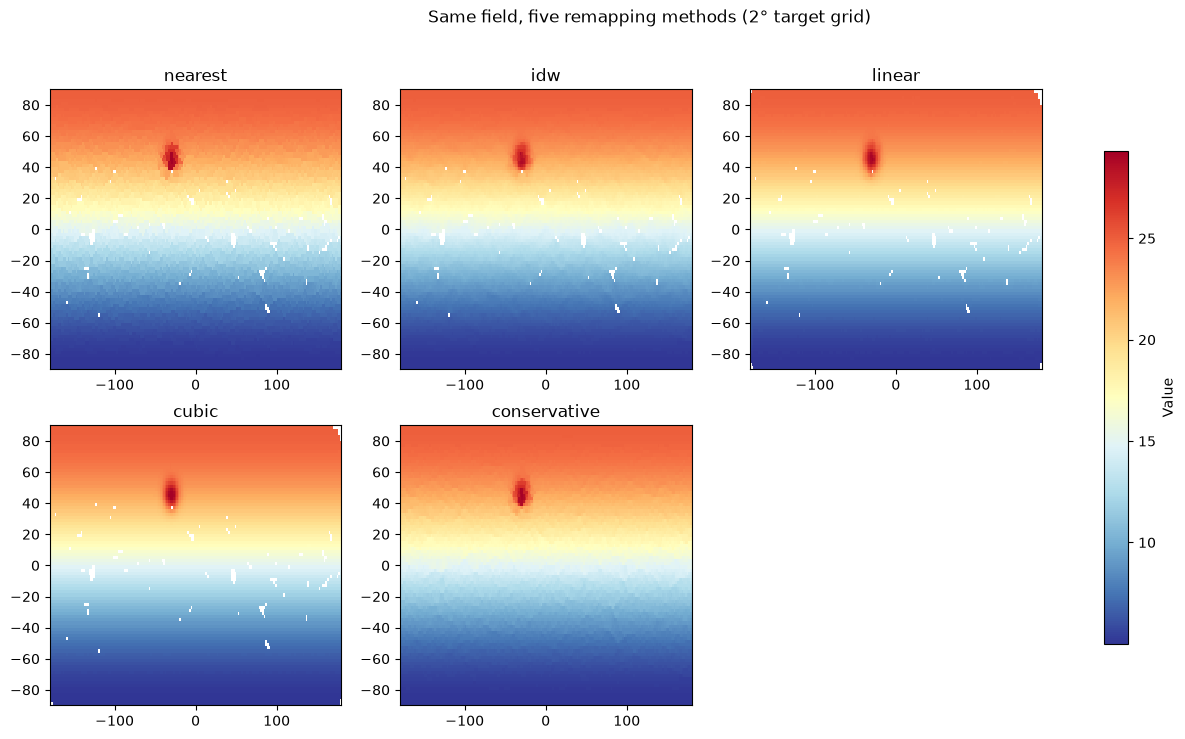

In [4]:
vmin, vmax = data.min(), data.max()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, method in zip(axes.flat, methods):
    r = results[method]
    interp = r["interp"]
    im = ax.pcolormesh(
        interp.target_lon, interp.target_lat, r["regridded"],
        cmap="RdYlBu_r", vmin=vmin, vmax=vmax, shading="auto",
    )
    ax.set_title(method)

axes.flat[-1].axis("off")
fig.colorbar(im, ax=axes, shrink=0.8, label="Value")
fig.suptitle("Same field, five remapping methods (2° target grid)", y=0.98)
plt.show()

Notice the blocky patches for `"nearest"`, the smoother gradients for `"idw"` /
`"linear"` / `"cubic"`, and how `"conservative"` looks similar to the smooth methods here
but is computing something fundamentally different under the hood (an area-weighted
average, not a point estimate — see Section 4).

## 3. Zooming in on the sharp anomaly

A finer regional regrid (0.5°, cropped to the North Atlantic-like region) makes the
differences much easier to see, especially the blockiness of `"nearest"`.

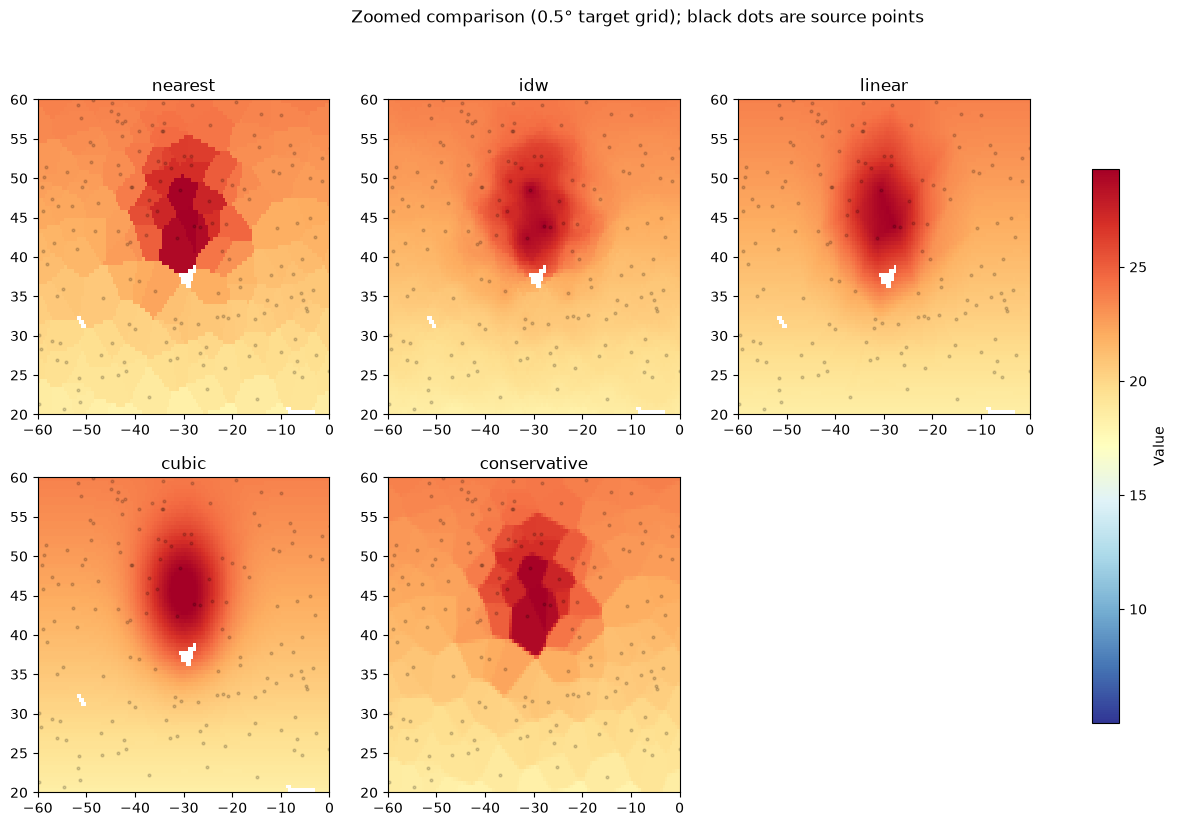

In [5]:
zoom_kwargs = dict(resolution=0.5, lon_bounds=(-60, 0), lat_bounds=(20, 60), influence_radius=500_000)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, method in zip(axes.flat, methods):
    interp = nr.RegridInterpolator(lon, lat, method=method, **zoom_kwargs)
    if method == "conservative":
        r, _ = interp(data, return_fraction=True)
    else:
        r = interp(data)
    im = ax.pcolormesh(
        interp.target_lon, interp.target_lat, r,
        cmap="RdYlBu_r", vmin=vmin, vmax=vmax, shading="auto",
    )
    ax.scatter(lon, lat, s=4, c="k", alpha=0.15)
    ax.set_xlim(-60, 0)
    ax.set_ylim(20, 60)
    ax.set_title(method)

axes.flat[-1].axis("off")
fig.colorbar(im, ax=axes, shrink=0.8, label="Value")
fig.suptitle("Zoomed comparison (0.5° target grid); black dots are source points", y=0.98)
plt.show()

## 4. Mass conservation

Only `"conservative"` guarantees
`sum(target_value * target_area) ≈ sum(source_value * source_area)`.
We check this directly: compute the true source integral from the (spherical) Voronoi
cell areas of the source points, and compare it to each method's regridded integral.

      nearest:   -1.04% error in the regridded total
          idw:   -1.04% error in the regridded total
       linear:   -1.04% error in the regridded total
        cubic:   -1.04% error in the regridded total
 conservative:   +0.06% error in the regridded total


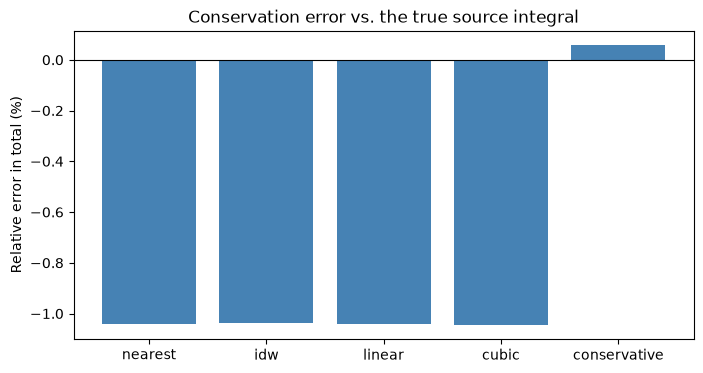

In [6]:
source_polys = build_voronoi_cells(lon, lat)
source_area = np.array([geometry_spherical_area(p) for p in source_polys])
source_integral = np.sum(data * source_area)

relative_errors = {}
for method in methods:
    r = results[method]
    interp = r["interp"]
    target_area = nr.core.grids.grid_cell_area(interp.target_lon, interp.target_lat)

    if method == "conservative":
        covered_area = target_area * r["fraction"]
        valid = np.isfinite(r["regridded"])
        target_integral = np.nansum(r["regridded"][valid] * covered_area[valid])
    else:
        valid = interp.valid_mask if hasattr(interp, "valid_mask") else np.isfinite(r["regridded"])
        valid = valid & np.isfinite(r["regridded"])
        target_integral = np.nansum(r["regridded"][valid] * target_area[valid])

    relative_errors[method] = 100 * (target_integral / source_integral - 1)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(relative_errors.keys(), relative_errors.values(), color="steelblue")
ax.axhline(0, color="k", linewidth=0.8)
ax.set_ylabel("Relative error in total (%)")
ax.set_title("Conservation error vs. the true source integral")
for method, err in relative_errors.items():
    print(f"{method:>13s}: {err:+7.2f}% error in the regridded total")
plt.show()

`"conservative"` stays close to zero error (limited only by the planar chord-area
approximation used for the Voronoi/overlap geometry); the point-interpolation methods
can drift noticeably because they were never designed to preserve totals.

## 5. Coverage fraction with missing source data

Now regrid the *masked* field (NaN over the synthetic continent). `"conservative"`'s
`valid_fraction` reports, per target cell, what fraction of its area was actually covered
by valid source data — similar to ESMF's `frac_b`. This lets you threshold/mask
low-confidence cells explicitly, rather than guessing from a single interpolated value.

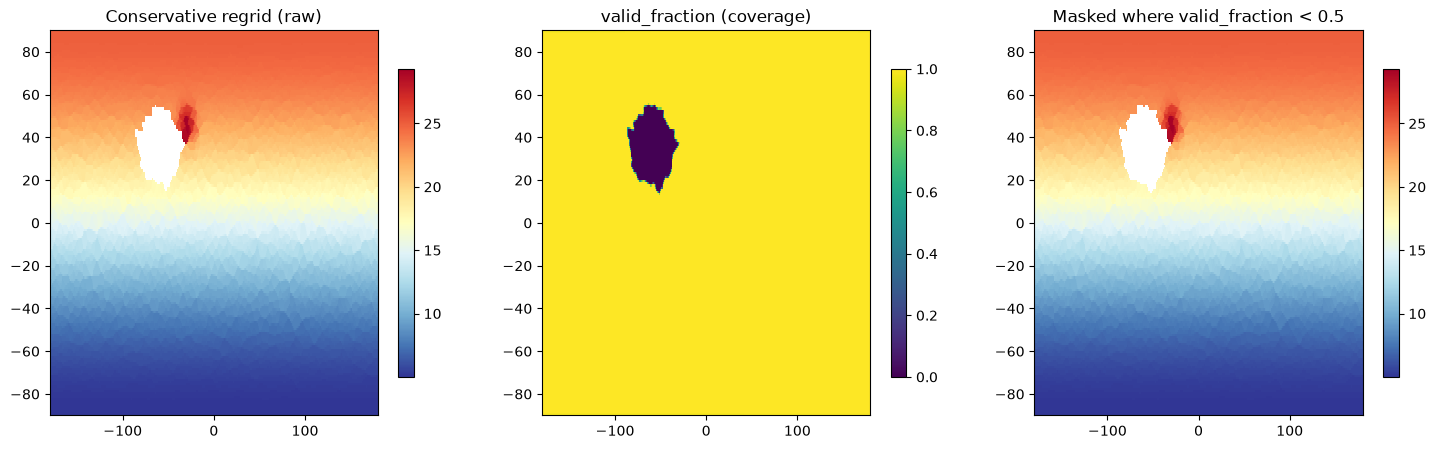

In [7]:
interp = nr.RegridInterpolator(lon, lat, resolution=1.0, method="conservative")
regridded_masked, fraction_masked = interp(data_masked, return_fraction=True)

# Mask out cells with less than 50% valid coverage
regridded_thresholded = np.where(fraction_masked >= 0.5, regridded_masked, np.nan)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

im0 = axes[0].pcolormesh(interp.target_lon, interp.target_lat, regridded_masked, cmap="RdYlBu_r", vmin=vmin, vmax=vmax)
axes[0].set_title("Conservative regrid (raw)")
plt.colorbar(im0, ax=axes[0], shrink=0.8)

im1 = axes[1].pcolormesh(interp.target_lon, interp.target_lat, fraction_masked, cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("valid_fraction (coverage)")
plt.colorbar(im1, ax=axes[1], shrink=0.8)

im2 = axes[2].pcolormesh(interp.target_lon, interp.target_lat, regridded_thresholded, cmap="RdYlBu_r", vmin=vmin, vmax=vmax)
axes[2].set_title("Masked where valid_fraction < 0.5")
plt.colorbar(im2, ax=axes[2], shrink=0.8)

plt.show()

## 6. Mesh-to-mesh conservative remapping

`"conservative"` is also the only method that can target another *unstructured* mesh
directly (`target_lon`/`target_lat` instead of `resolution`) — useful for remapping
directly between two model grids, e.g. FESOM to ICON, without going through a regular
grid as an intermediate step.

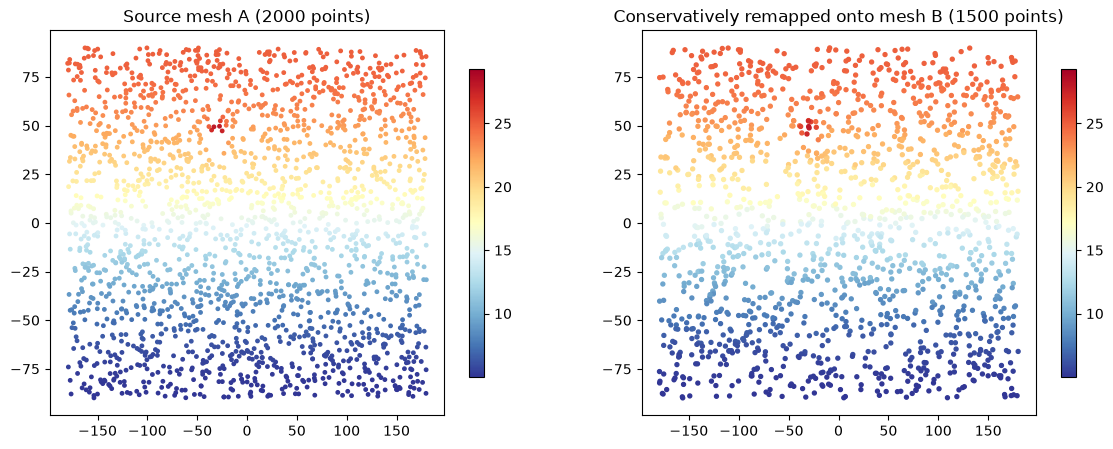

Mean coverage fraction on mesh B: 0.993


In [8]:
rng_a = np.random.default_rng(1)
rng_b = np.random.default_rng(2)

lon_a, lat_a = rng_a.uniform(-180, 180, 2000), rng_a.uniform(-90, 90, 2000)
lon_b, lat_b = rng_b.uniform(-180, 180, 1500), rng_b.uniform(-90, 90, 1500)

data_a = 15 + 10 * np.sin(np.deg2rad(lat_a)) + 8 * np.exp(
    -(((lon_a - (-30)) ** 2 + (lat_a - 45) ** 2) / (2 * 6.0 ** 2))
)

mesh_to_mesh = nr.RegridInterpolator(
    lon_a, lat_a, method="conservative", target_lon=lon_b, target_lat=lat_b,
)
data_b, fraction_b = mesh_to_mesh(data_a, return_fraction=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc0 = axes[0].scatter(lon_a, lat_a, c=data_a, s=6, cmap="RdYlBu_r", vmin=vmin, vmax=vmax)
axes[0].set_title(f"Source mesh A ({len(lon_a)} points)")
plt.colorbar(sc0, ax=axes[0], shrink=0.8)

sc1 = axes[1].scatter(lon_b, lat_b, c=data_b, s=8, cmap="RdYlBu_r", vmin=vmin, vmax=vmax)
axes[1].set_title(f"Conservatively remapped onto mesh B ({len(lon_b)} points)")
plt.colorbar(sc1, ax=axes[1], shrink=0.8)

plt.show()
print(f"Mean coverage fraction on mesh B: {np.nanmean(fraction_b):.3f}")

## Summary

| Method | Best for | Drawback |
|---|---|---|
| `"nearest"` | fast exploration, high-res source data | blocky with coarse source data |
| `"idw"` | fast, smooth, general purpose | less accurate than triangulation-based methods |
| `"linear"` | smooth visualization, coarse source data | slower; long triangles possible over gaps |
| `"cubic"` | smoothest results, presentation plots | slowest of the point methods; can overshoot |
| `"conservative"` | budget/flux diagnostics, mesh-to-mesh remapping | slowest to build; approximate cell geometry |

`"conservative"` weights are precomputed once in `RegridInterpolator.__post_init__` and
reused for every subsequent call (e.g. every time level), so the one-time build cost
amortizes well over repeated application — see the timings in Section 2.